In [1]:
import pandas as pd
import numpy as np

meta = pd.read_csv("../data/raw/proteomic/all_subtypes.v5.1.tsv",sep = '\t')
meta['rna_wang_cancer_cell_2017'].unique()
tumor_id = meta[meta["sample_type"] == "tumor"]["case"].tolist()
proneural_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Proneural']['case'].tolist()
mesenchymal_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Mesenchymal']['case'].tolist()
classical_id = meta[meta['rna_wang_cancer_cell_2017'] == 'Classical']['case'].tolist()
idh_id = meta[meta['rna_wang_cancer_cell_2017'] == 'IDH mutant']['case'].tolist()
normal_id = meta[meta["sample_type"] == "GTEx normal"]["case"].tolist()
normal_id.pop(2)

meta

,case,sample_type,multiomic,nmf_consensus,nmf_cluster_membership,rna_wang_cancer_cell_2017,mRNA_stemness_index,dna_methyl,dna_methyl_consensus,is_gcimp,...,PDGFRA_alter_status,PIK3CA_alter_status,BRAF_alter_status,RB1_alter_status,ATRX_alter_status,IDH1_alter_status,PIK3R1_alter_status,TERT_alter_status,chr7_amp,chr10_del
0,C3L-00104,tumor,nmf1,nmf1,0.743,Proneural,0.678244,dm2,0.314081,True,...,NaN,NaN,NaN,Splice_Site,NaN,NaN,NaN,Promoter,True,True
1,C3L-00365,tumor,nmf3,nmf3,0.614,Classical,0.681122,dm4,0.891149,False,...,NaN,NaN,NaN,Frame_Shift,NaN,NaN,NaN,Promoter,True,True
2,C3L-00674,tumor,nmf1,nmf1,0.507,Mesenchymal,0.744635,dm5,0.625634,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Promoter,True,True
3,C3L-00677,tumor,nmf1,nmf1,0.536,Proneural,0.900896,dm5,0.406474,False,...,NaN,NaN,NaN,Splice_Site,Nonsense,NaN,NaN,NaN,True,True
4,C3L-01040,tumor,nmf1,nmf1,0.589,Classical,0.647288,dm5,0.623458,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Promoter,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,PT-RN5K,GTEx normal,NaN,NaN,NaN,NaN,0.005667,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,PT-RU72,GTEx normal,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,PT-UTHO,GTEx normal,NaN,NaN,NaN,NaN,0.029399,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,PT-WVLH,GTEx normal,NaN,NaN,NaN,NaN,0.168976,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:

rna = pd.read_csv(
    "../data/raw/Gene_Expression_RNA/rnaseq_washu_fpkm_uq.v4.0.tsv.gz",
    sep="\t"
)
rna = rna.drop(['gene_id','gene_type','gene_status','havana_gene','full_length','exon_length','exon_num'],axis=1).set_index('gene_name')
print(rna.shape)
rna = np.log2(rna + 1)

pro = pd.read_csv("../data/interim/diff/de_proteome.csv").set_index("gene")
proset = set(pro.index)
rnaset = set(rna.index)

common = list(proset & rnaset)
print(common)
print(len(common))

rna = rna.T
rna = rna[common]
rna = rna.T

(60483, 108)
['NFU1', 'FAM162B', 'NAA10', 'NDFIP1', 'OSGEP', 'PYGO1', 'TOMM22', 'TPMT', 'EPS8', 'COL4A2', 'CCDC58', 'XIRP1', 'MRPL2', 'PRPSAP2', 'DET1', 'FAM219A', 'DPH3', 'LHPP', 'KPNB1', 'PGBD5', 'ENSA', 'GP1BB', 'RNASE3', 'RPL18A', 'MFN2', 'SRRM1', 'SNAPIN', 'GPD1', 'DCAF16', 'KIF1A', 'DIS3', 'TAMM41', 'NRCAM', 'RPS14', 'SLC12A5', 'COLGALT1', 'BLOC1S6', 'PLIN3', 'DNAJB9', 'RPIA', 'TCERG1', 'NTPCR', 'RPRD2', 'ZFAND3', 'ARPC1A', 'UBL4A', 'ELMOD1', 'UTP15', 'BBX', 'HAUS3', 'RPL36A', 'DHRS4', 'HOMER3', 'N4BP2', 'ZNF3', 'RNASE6', 'TGFB3', 'KLC4', 'MAT2B', 'ZBED8', 'SERPINA5', 'POLI', 'CALR', 'CAB39L', 'SLFN5', 'NAA30', 'TRPC4AP', 'CD2BP2', 'ASAP2', 'ATP11B', 'FERMT3', 'GALE', 'MBOAT7', 'NFKBIB', 'TRAPPC4', 'RAB39A', 'YIF1B', 'RBMS3', 'SAA2', 'ZC3H6', 'MPG', 'MRPL18', 'HIST1H1B', 'RALYL', 'EGR1', 'UBR7', 'ABCB7', 'NDN', 'TUBGCP3', 'STRN3', 'NRXN1', 'JAG1', 'RPP25L', 'PREP', 'CCT6A', 'SERPINA7', 'ERAP2', 'EIF4A2', 'GINS3', 'BRD2', 'ARRB1', 'TMED7', 'MTERF4', 'WDR35', 'CYB5R1', 'RNF169', 'A

In [3]:
gbm_expr = rna[tumor_id]
proneural_expr = rna[proneural_id]
mesenchymal_expr = rna[mesenchymal_id]
classical_expr = rna[classical_id]
idh_expr = rna[idh_id]
normal_expr = rna[normal_id]
normal_expr
classical_expr

,C3L-00365,C3L-01040,C3L-01048,C3L-01061,C3L-01154,C3L-01155,C3L-01156,C3L-01327,C3L-01887,C3L-02642,...,C3L-04084,C3N-01196,C3N-01334,C3N-01368,C3N-01517,C3N-01852,C3N-01857,C3N-02782,C3N-03184,C3N-03188
gene_name,,,,,,,,,,,,,,,,,,,,,
NFU1,16.845096,16.750506,16.543463,16.973399,16.874809,16.676359,17.173572,17.038959,16.924311,16.986179,...,16.990307,17.094475,16.935166,17.126192,16.775243,16.863746,16.692723,17.194267,16.663983,16.579900
FAM162B,13.391309,15.936524,12.603806,13.558173,13.165733,15.140887,13.879124,14.642971,15.208157,14.082443,...,14.369399,13.409454,14.252334,13.079003,14.825520,13.244874,13.932659,13.247698,14.298519,15.560090
NAA10,16.778813,16.600025,17.479109,17.267472,17.183642,17.064135,17.133874,16.712709,16.809333,16.906684,...,16.685547,16.685183,16.594221,16.731435,17.272643,17.270507,16.498332,17.170990,16.936877,17.337370
NDFIP1,19.253780,19.414098,18.668517,18.767390,19.072311,18.626792,19.307556,19.205514,19.036719,19.352718,...,19.424130,19.279959,19.461941,19.620124,18.869582,19.129430,19.644748,18.782799,18.747438,19.712038
OSGEP,17.603782,17.780661,18.483742,18.258084,17.855887,17.857833,18.000341,17.824352,17.991283,17.249644,...,17.881621,18.068996,17.261560,17.950853,18.406691,17.541460,17.738495,18.477370,17.892552,17.706132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MED29,18.670035,18.784483,19.055224,18.257320,18.684085,18.496212,18.629683,18.722682,18.380442,19.661765,...,18.563765,18.447913,18.742674,18.678477,18.782279,19.085580,18.845267,18.512143,18.872020,18.656906
CSK,16.371431,16.826370,17.497836,17.654498,17.345393,17.586616,16.951815,16.669516,16.802763,17.368545,...,17.007145,17.005127,16.995181,16.741810,16.988092,17.236279,17.588417,16.938015,16.868260,16.934916
P4HB,20.303515,20.053099,19.915225,20.376779,20.432615,20.085997,19.843959,19.880396,19.767541,19.334385,...,19.925484,19.967590,19.905235,19.996411,20.400197,20.424325,19.515971,20.702417,19.947620,20.150656


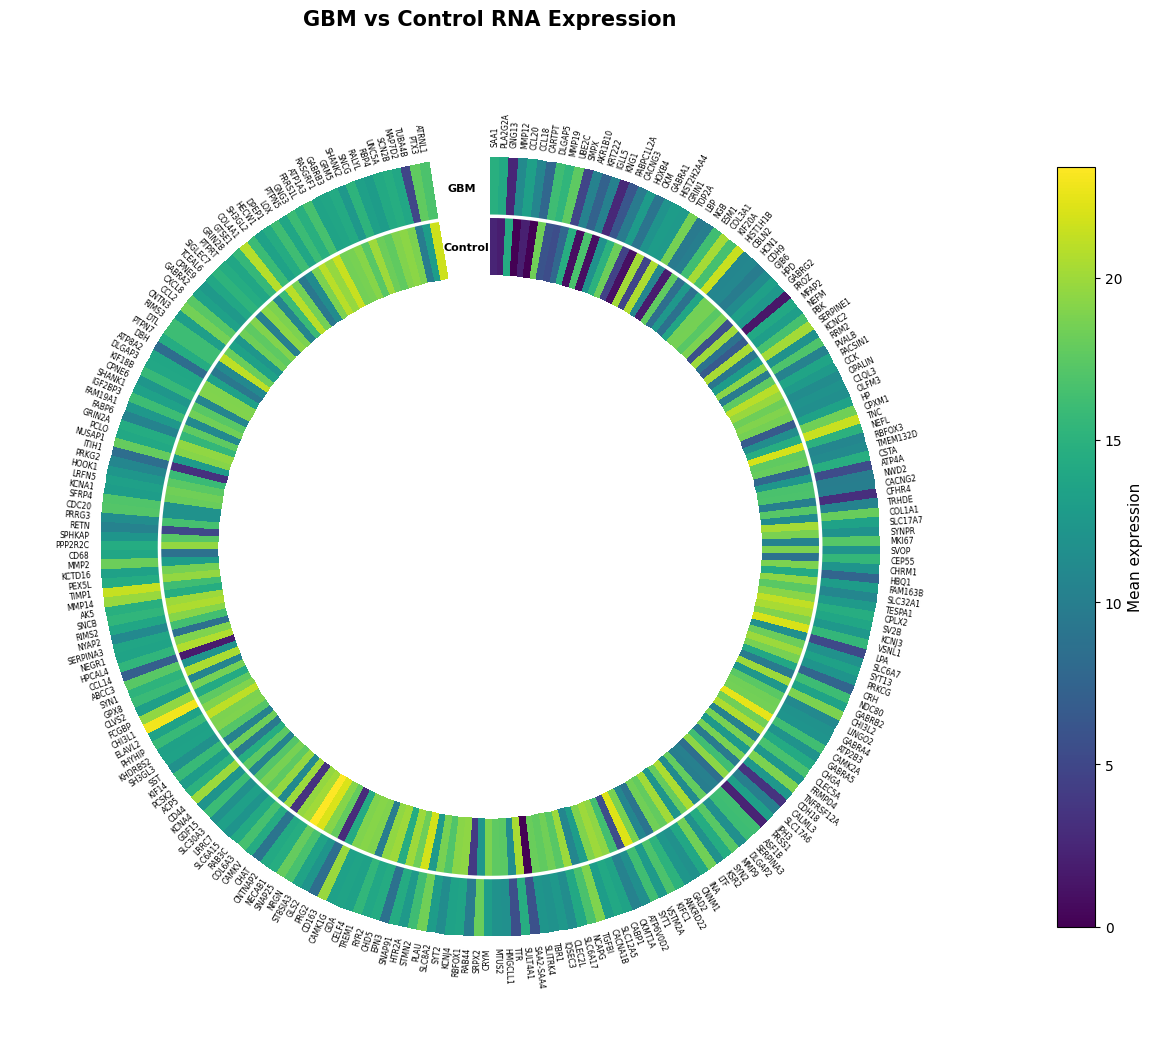

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize


# ============================================================
# DATA
# ============================================================

avg_norm = normal_expr.mean(axis=1)
avg_clas = gbm_expr.mean(axis=1)

plot_df = pd.DataFrame({
    "Normal": avg_norm,
    "Classical": avg_clas
}).dropna()


# ============================================================
# SELECT GENES
# ============================================================

n_genes = 250

plot_df["abs_diff"] = (
    plot_df["Classical"] - plot_df["Normal"]
).abs()

plot_df = (
    plot_df
    .sort_values("abs_diff", ascending=False)
    .head(n_genes)
    .drop(columns="abs_diff")
)


# ============================================================
# MATRIX
# ============================================================

# Row 0 = Normal
# Row 1 = Classical

Z = plot_df[
    ["Normal", "Classical"]
].T.to_numpy()

n_rings, n_cols = Z.shape

gene_names = plot_df.index.astype(str).tolist()


# ============================================================
# CIRCULAR GEOMETRY
# ============================================================

# Only a very small gap.
# This prevents the giant "missing wedge" appearance.

gap_ratio = 0.025

full_circle = 2 * np.pi

theta_start = 0
theta_end = full_circle * (1 - gap_ratio)

theta_edges = np.linspace(
    theta_start,
    theta_end,
    n_cols + 1
)


# Overall size of the heatmap

inner_radius = 3.0
ring_width = 0.65

middle_radius = inner_radius + ring_width
outer_radius = middle_radius + ring_width


r = np.array([
    inner_radius,
    middle_radius,
    outer_radius
])


T, R = np.meshgrid(
    theta_edges,
    r
)


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 14),
    subplot_kw={"projection": "polar"}
)

ax.set_theta_direction(-1)

# Start at 12 o'clock
ax.set_theta_offset(np.pi / 2)


# ============================================================
# EXPRESSION COLOR SCALE
# ============================================================

norm = Normalize(
    vmin=np.nanmin(Z),
    vmax=np.nanmax(Z)
)

cmap = plt.cm.viridis


mesh = ax.pcolormesh(
    T,
    R,
    Z,
    cmap=cmap,
    norm=norm,
    shading="flat"
)


# ============================================================
# NORMAL / CLASSICAL SEPARATOR
# ============================================================

theta_line = np.linspace(
    theta_start,
    theta_end,
    1000
)

ax.plot(
    theta_line,
    np.full_like(theta_line, middle_radius),
    color="white",
    linewidth=2.5,
    zorder=10
)


# ============================================================
# AXIS LIMITS
# ============================================================

label_radius = outer_radius + 0.55

ax.set_ylim(
    0,
    label_radius + 0.45
)


# ============================================================
# REMOVE POLAR AXIS
# ============================================================

ax.set_xticks([])
ax.set_yticks([])

ax.grid(False)

ax.spines["polar"].set_visible(False)


# ============================================================
# SAMPLE LABELS
# ============================================================

# Put the labels in the small gap.
#
# Since the gap is now very small, put them slightly
# inside the donut rather than trying to squeeze them
# between the gene labels.

gap_angle = (
    theta_end + full_circle
) / 2


# Classical = outer ring

ax.text(
    gap_angle,
    middle_radius + ring_width * 0.5,
    "GBM",
    ha="center",
    va="center",
    fontsize=8,
    fontweight="bold",
    rotation=0
)


# Normal = inner ring

ax.text(
    gap_angle,
    inner_radius + ring_width * 0.5,
    "Control",
    ha="center",
    va="center",
    fontsize=8,
    fontweight="bold"
)


# ============================================================
# GENE LABELS
# ============================================================

label_radius = outer_radius + 0.12

for i, gene in enumerate(gene_names):

    # Center angle of the gene wedge
    angle = (
        theta_edges[i] +
        theta_edges[i + 1]
    ) / 2

    # --------------------------------------------------------
    # IMPORTANT:
    # Because the polar axis has:
    #
    #     theta_offset = 90 degrees
    #     theta_direction = -1
    #
    # the actual visual angle on the page is:
    #
    #     90 - theta
    # --------------------------------------------------------

    visual_angle = 90 - np.degrees(angle)

    # Normalize to 0-360
    visual_angle = visual_angle % 360

    # --------------------------------------------------------
    # Make text point OUTWARD along the wedge/radius
    # --------------------------------------------------------

    rotation = visual_angle

    # --------------------------------------------------------
    # Keep text readable on the left side.
    # Flip it 180 degrees rather than letting it become
    # upside-down.
    # --------------------------------------------------------

    if 90 < visual_angle < 270:
        rotation += 180
        ha = "right"
    else:
        ha = "left"

    ax.text(
        angle,
        label_radius,
        gene,
        rotation=rotation,
        rotation_mode="anchor",
        ha=ha,
        va="center",
        fontsize=5.5,
        clip_on=False
    )

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    mesh,
    ax=ax,
    fraction=0.035,
    pad=0.08,
    shrink=0.75
)

cbar.set_label(
    "Mean expression",
    fontsize=11
)


# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "GBM vs Control RNA Expression",
    fontsize=15,
    fontweight="bold",
    pad=30
)


# ============================================================
# SAVE
# ============================================================

plt.savefig(
    "../data/interim/network_stat/"
    "classical_normal_vs_classical_circular_heatmap.svg",
    format="svg",
    bbox_inches="tight"
)


plt.show()

In [ ]:
print(proneural_expr.shape)
print(mesenchymal_expr.shape)
print(classical_expr.shape)

print(proneural_expr.columns[:5])
print(mesenchymal_expr.columns[:5])
print(classical_expr.columns[:5])

(10121, 29)
(10121, 39)
(10121, 25)
Index(['C3L-00104', 'C3L-00677', 'C3L-01146', 'C3L-01149', 'C3L-01157'], dtype='str')
Index(['C3L-00674', 'C3L-01043', 'C3L-01045', 'C3L-01046', 'C3L-01049'], dtype='str')
Index(['C3L-00365', 'C3L-01040', 'C3L-01048', 'C3L-01061', 'C3L-01154'], dtype='str')


In [7]:
def keep_highest_max_duplicate(df):
    return (
        df.assign(_max=df.max(axis=1))
          .sort_values("_max", ascending=False)
          .groupby(level=0)
          .first()
          .drop(columns="_max")
    )

datasets = {
    'gbm': gbm_expr,
    "proneural": proneural_expr,
    "mesenchymal": mesenchymal_expr,
    "classical": classical_expr,
    "idh": idh_expr,
    "normal": normal_expr
}

datasets = {
    name: keep_highest_max_duplicate(df)
    for name, df in datasets.items()
}

gbm_expr = datasets['gbm']
proneural_expr = datasets["proneural"]
mesenchymal_expr = datasets["mesenchymal"]
classical_expr = datasets["classical"]
idh_expr = datasets["idh"]
normal_expr = datasets["normal"]

# Import diffential analysis module

In [5]:
import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)


<module 'diff' from 'c:\\Users\\haina\\Desktop\\BIO_RA\\notebooks\\../src\\diff.py'>

# Entire dataset

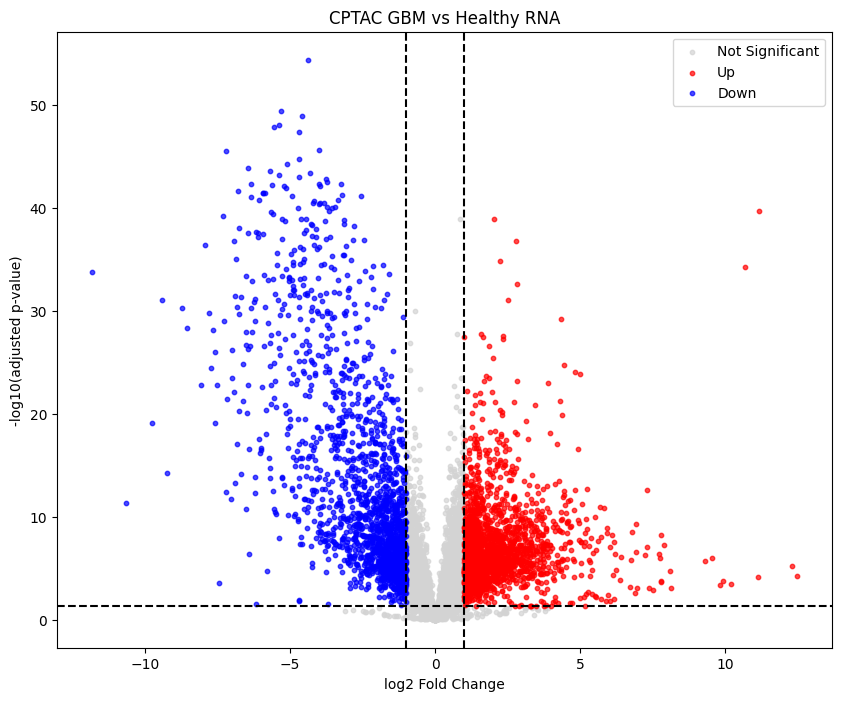

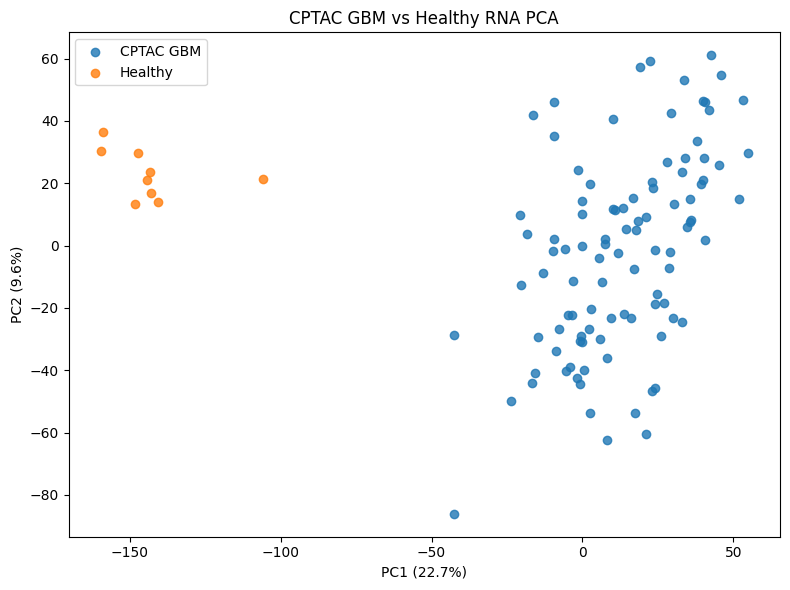

In [ ]:
gbm = diff.differential_expression(gbm_expr,normal_expr)
diff.volcano_plot(gbm,'CPTAC GBM vs Healthy RNA')
diff.pca_plot(gbm_expr,normal_expr,'CPTAC GBM','Healthy','CPTAC GBM vs Healthy RNA PCA')
gbm.to_csv('../data/interim/CPTAC_rna_diff.csv')

# Proneural 

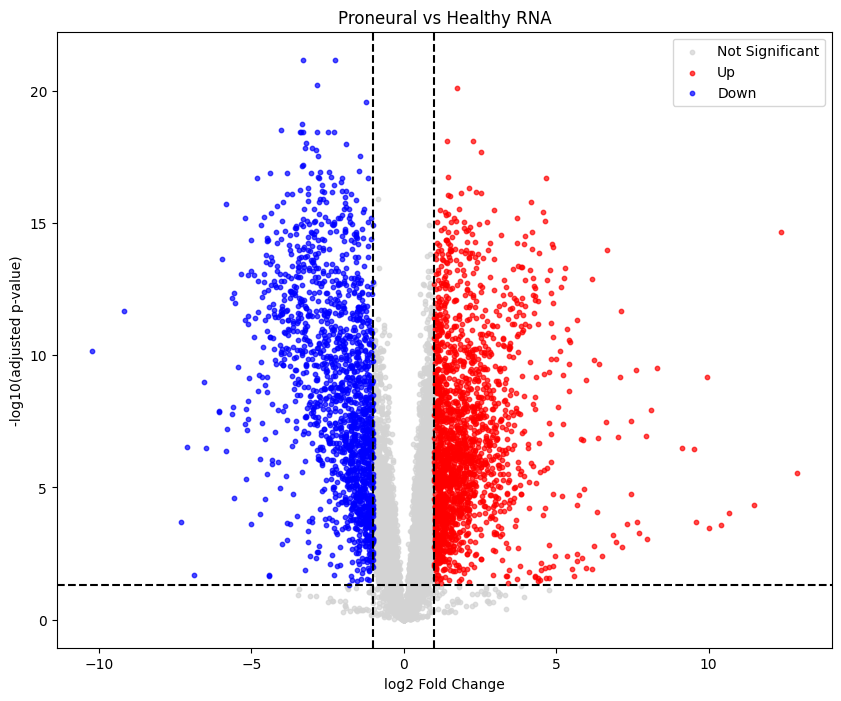

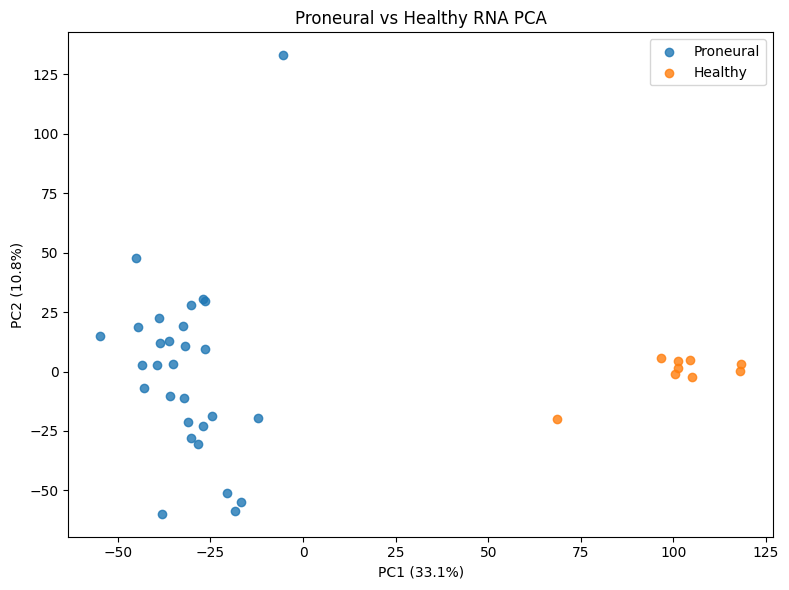

In [ ]:
pro = diff.differential_expression(proneural_expr,normal_expr)
diff.volcano_plot(pro,'Proneural vs Healthy RNA')
diff.pca_plot(proneural_expr,normal_expr,'Proneural','Healthy','Proneural vs Healthy RNA PCA')
pro.to_csv('../data/interim/proneural_rna_diff.csv')

# Mesenchymal

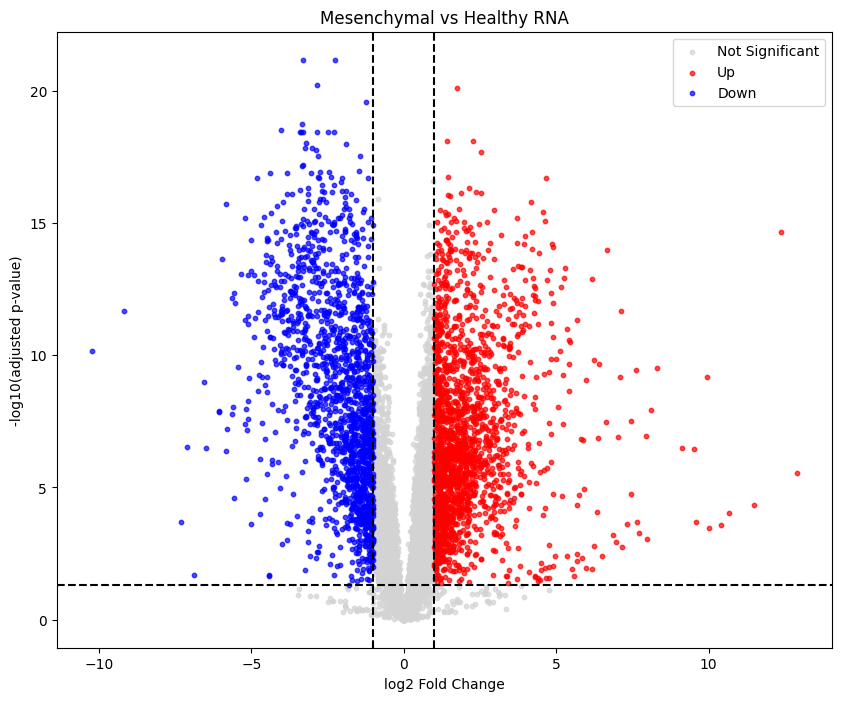

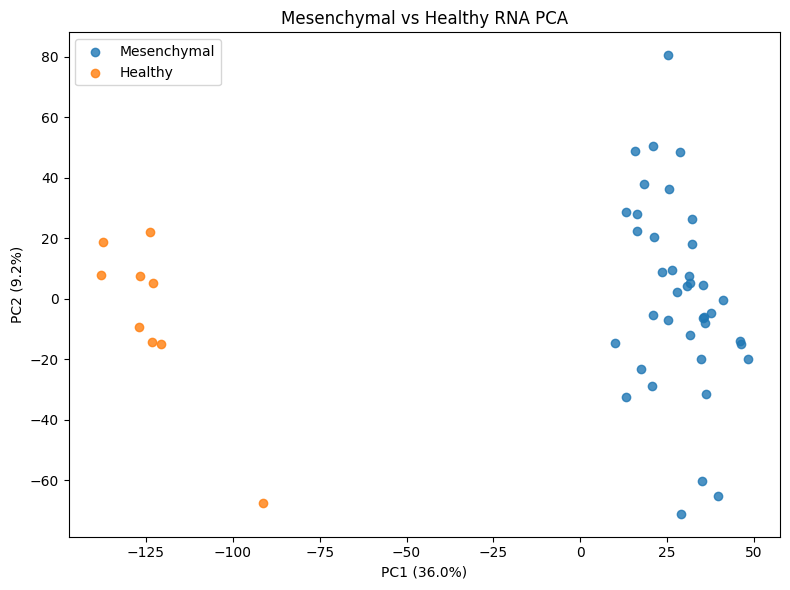

In [ ]:
mes = diff.differential_expression(mesenchymal_expr,normal_expr)
diff.volcano_plot(mes,'Mesenchymal vs Healthy RNA')
diff.pca_plot(mesenchymal_expr,normal_expr,'Mesenchymal','Healthy','Mesenchymal vs Healthy RNA PCA')
mes.to_csv('../data/interim/mesenchymal_rna_diff.csv')

# Classical

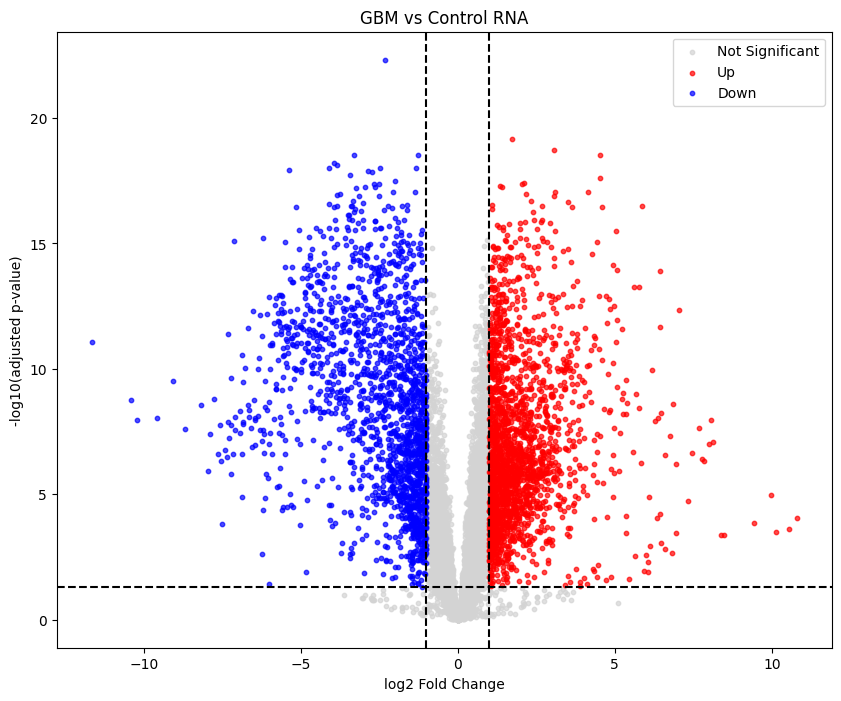

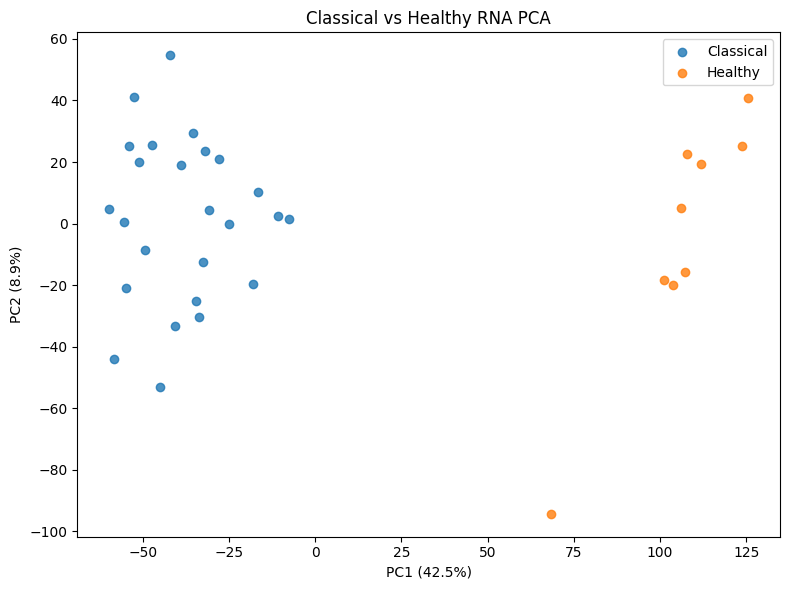

In [ ]:
clas = diff.differential_expression(classical_expr,normal_expr)
diff.volcano_plot(clas,'Classical vs Healthy RNA')
diff.pca_plot(classical_expr,normal_expr,'Classical','Healthy','Classical vs Healthy RNA PCA')
clas.to_csv('../data/interim/classical_rna_diff.csv')

# IDH

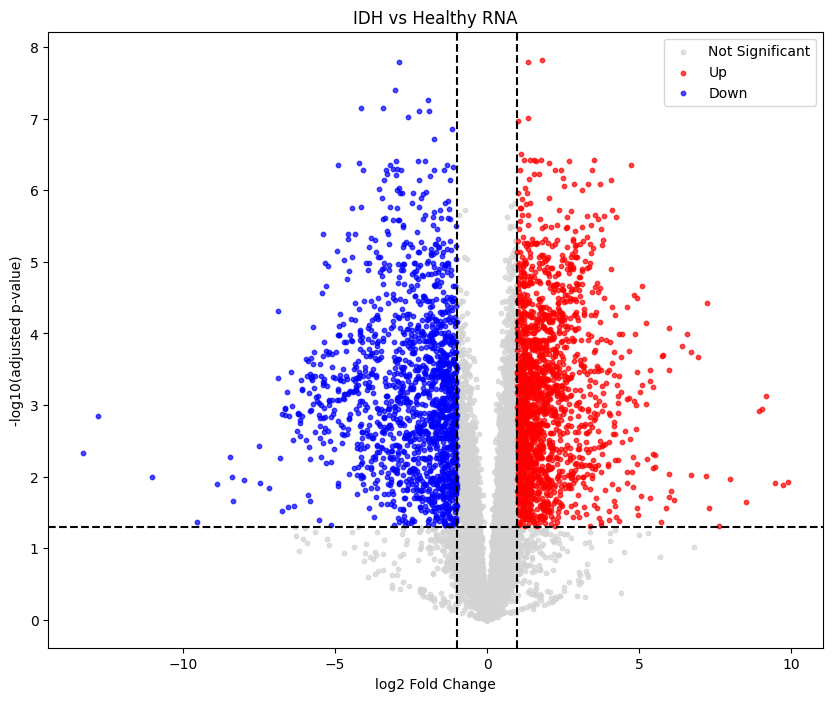

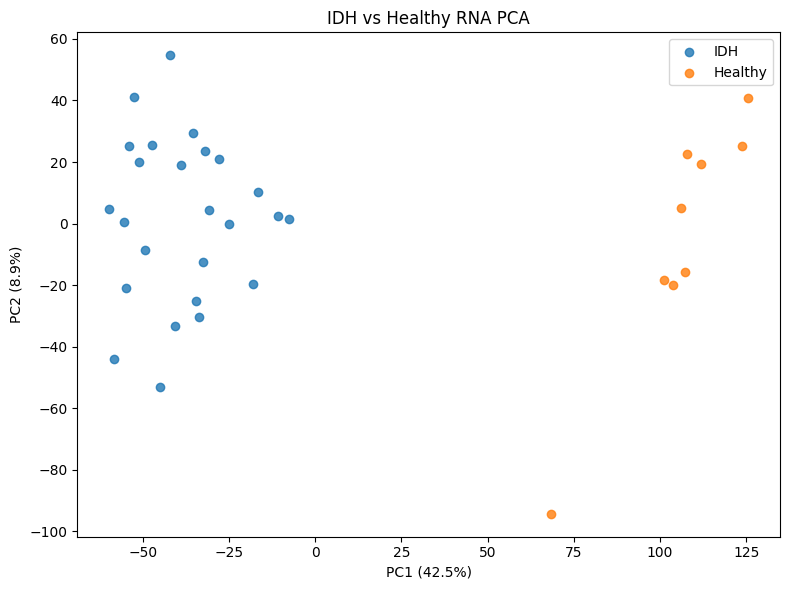

In [ ]:
idh = diff.differential_expression(idh_expr,normal_expr)
diff.volcano_plot(idh,'IDH vs Healthy RNA')
diff.pca_plot(idh_expr,normal_expr,'IDH','Healthy','IDH vs Healthy RNA PCA')
idh.to_csv('../data/interim/idh_rna_diff.csv')